In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pickle
import joblib
import numpy as np

import sinter
import os

from matplotlib.animation import FuncAnimation, PillowWriter

from qecsim.lattice_surgery.circuit import surgery_circuit
from qecsim.threshold_num.calc_threshold import threshold_approx

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

In [3]:
#surgery_circuit(distance = 5, round_merge = 2, round_split = 2,round_num = 2, target_state_init="X+", control_state_init="X+", flow_observable = "X -> XX"). diagram("timeslice-svg")

In [4]:
# Load all Lists by fixed Rounds (dependent from distance -> d, d*2, d2/3)
stats_norm = joblib.load("Pckl Data/lscx_singlerounds_combined.pkl")
stats_double = joblib.load("Pckl Data/lscx_doublerounds_combined.pkl")
stats_3 = joblib.load("Pckl Data/lscx_twothirdrounds_combined.pkl")
stats_double_merge = joblib.load("Pckl Data/lscx_doublerounds_merge_combined.pkl")
stats_double_split = joblib.load("Pckl Data/lscx_doublerounds_split_combined.pkl")
stats_3_merge = joblib.load("Pckl Data/lscx_twothirdrounds_merge_combined.pkl")
stats_3_split = joblib.load("Pckl Data/lscx_twothirdrounds_split_combined.pkl")
stats_double_init = joblib.load("Pckl Data/lscx_doublerounds_init_combined.pkl")
stats_3_init = joblib.load("Pckl Data/lscx_twothirdrounds_init_combined.pkl")

# Load all List by Rounds (independent from distance r = 2,4...)
stats_2r = joblib.load("lscx_singlerounds_2_combined.pkl")
stats_4r = joblib.load("lscx_singlerounds_4_combined.pkl")
stats_6r = joblib.load("lscx_singlerounds_6_combined.pkl")
stats_8r = joblib.load("lscx_singlerounds_8_combined.pkl")
stats_10r = joblib.load("lscx_singlerounds_10_combined.pkl")

In [5]:
#Create Dictionary and sort into Distance Pairs (Rounds dependent on distance)
distances = sorted(set(stat.json_metadata["distance"] for stat in stats_norm))

red_dict_norm : dict = {}
red_dict_double : dict = {}
red_dict_3 : dict = {}
red_dict_double_merge : dict = {}
red_dict_3_merge : dict = {}
red_dict_double_split : dict = {}
red_dict_3_split : dict = {}
red_dict_double_init : dict = {}
red_dict_3_init : dict = {}

for d in range(0,len(distances)-1):
    red_dict_norm[distances[d]] = [stat for stat in stats_norm if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double[distances[d]] = [stat for stat in stats_double if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3[distances[d]] = [stat for stat in stats_3 if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_merge[distances[d]] = [stat for stat in stats_double_merge if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_merge[distances[d]] = [stat for stat in stats_3_merge if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_split[distances[d]] = [stat for stat in stats_double_split if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_split[distances[d]] = [stat for stat in stats_3_split if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_init[distances[d]] = [stat for stat in stats_double_init if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_init[distances[d]] = [stat for stat in stats_3_init if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]

#Create Dictionary and sort into Distance Pairs (Rounds independent on distance)

red_dict_2r : dict = {}
red_dict_4r : dict = {}
red_dict_6r : dict = {}
red_dict_8r : dict = {}
red_dict_10r : dict = {}

#Changing resolution as there are too many data point over 5e-4

fine_list   = np.arange(1e-5, 0.013, 5e-5)
sparse_list = np.arange(1, 2, 1)

for d in range(0,len(distances)-1):

    red_dict_2r[distances[d]] = [stat for stat in stats_2r if stat.json_metadata["distance"] in {distances[d], distances[d+1]} 
                                 if stat.json_metadata["p"] in list(fine_list) + list(sparse_list)]
    red_dict_4r[distances[d]] = [stat for stat in stats_4r if stat.json_metadata["distance"] in {distances[d], distances[d+1]}
                                 if stat.json_metadata["p"] in list(fine_list) + list(sparse_list)]
    red_dict_6r[distances[d]] = [stat for stat in stats_6r if stat.json_metadata["distance"] in {distances[d], distances[d+1]}
                                 if stat.json_metadata["p"] in list(fine_list) + list(sparse_list)]
    red_dict_8r[distances[d]] = [stat for stat in stats_8r if stat.json_metadata["distance"] in {distances[d], distances[d+1]}
                                 if stat.json_metadata["p"] in list(fine_list) + list(sparse_list)]
    red_dict_10r[distances[d]] = [stat for stat in stats_10r if stat.json_metadata["distance"] in {distances[d], distances[d+1]}
                                  if stat.json_metadata["p"] in list(fine_list) + list(sparse_list)]

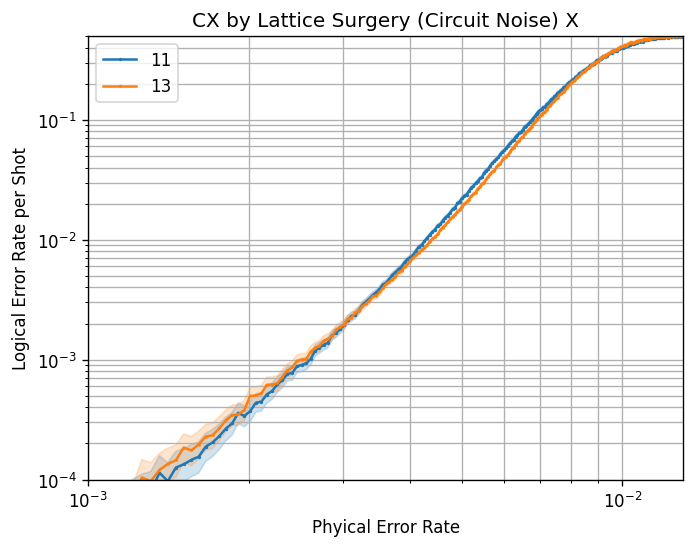

In [20]:
##################
# Plotting X Noise
##################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats = red_dict_6r[11],
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])

"""
THIS IS TO MAKE THE MARKERS SMALLER (FROM GPT)
"""
for coll in ax.collections:
    if hasattr(coll, "set_sizes"):
        coll.set_sizes([9] * len(coll.get_sizes()))
for line in ax.lines:
    if hasattr(line, "set_markersize"):
        line.set_markersize(1)   # try 2–4

ax.loglog()
ax.set_xlim(1e-3,1.3e-2)
ax.set_ylim(1e-4, 0.5)
ax.set_title("CX by Lattice Surgery (Circuit Noise) X")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

Distance_5_save_successful
Distance_7_save_successful
Distance_9_save_successful
Distance_11_save_successful


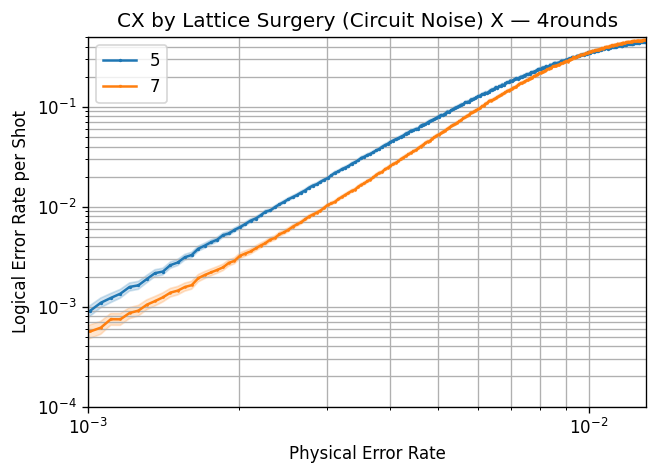

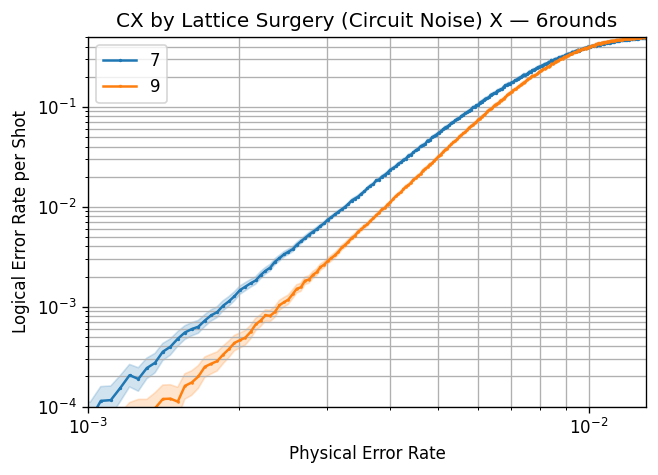

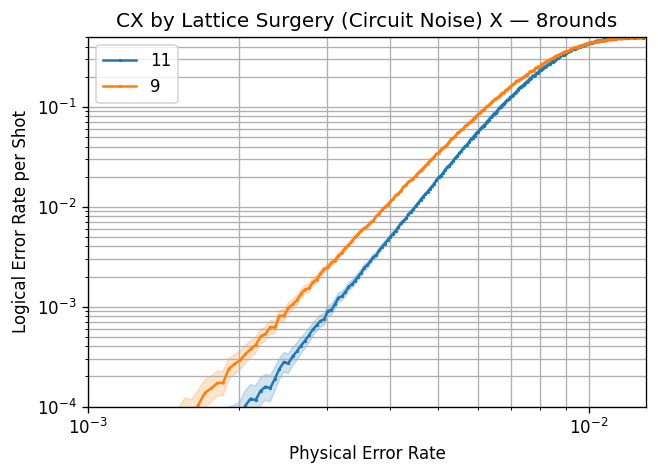

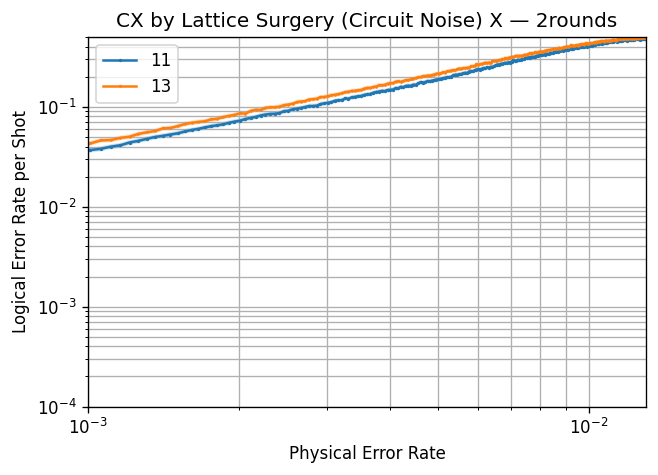

In [21]:
# Creating Gif for all Distances cycling thorugh the rounds
for dist_key in [5,7,9,11]:

    frames_data : list= []
    dict_list = [red_dict_2r, red_dict_4r, red_dict_6r, red_dict_8r, red_dict_10r]

    # Create list of the different frames given by rounds function
    for index, num_rounds in enumerate(range(2, dist_key, 2)):
        frames_data.append((str(num_rounds) + "rounds", dict_list[index]))

    # Shrink markers due to too high density of sample points
    def shrink_markers(ax):
        for coll in ax.collections:
            if hasattr(coll, "set_sizes"):
                coll.set_sizes([9] * len(coll.get_sizes()))
        for line in ax.lines:
            if hasattr(line, "set_markersize"):
                line.set_markersize(1)

    # Setting Y-Lims
    Y_LIMS = (1e-4, 0.5)

    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=120)

    def draw_frame(i):
        title, data_dict = frames_data[i]
        ax.clear()

        sinter.plot_error_rate(
            ax=ax,
            stats=data_dict[dist_key],
            x_func=lambda s: s.json_metadata['p'],
            group_func=lambda s: s.json_metadata['distance'],
        )

        shrink_markers(ax)

        ax.loglog()
        ax.set_xlim(1e-3, 1.3e-2)
        if Y_LIMS is not None:
            ax.set_ylim(*Y_LIMS)
        ax.set_title(f"CX by Lattice Surgery (Circuit Noise) X — {title}")
        ax.set_xlabel("Physical Error Rate")
        ax.set_ylabel("Logical Error Rate per Shot")
        ax.grid(which='major')
        ax.grid(which='minor')
        ax.legend(loc="best")

        return ax.collections + ax.lines

    anim = FuncAnimation(
        fig, draw_frame,
        frames=len(frames_data),
        # Setting ms per frame
        interval=2400,
        blit=False,
        repeat=True
    )

    # Save as GIF (0 -> Infinite Loop)
    writer = PillowWriter(fps=1, metadata={'loop': 0})
    anim.save(str(dist_key) + "_x_noise_by_rounds.gif", writer=writer)
    print("Distance_" + str(dist_key) + "_save_successful")

In [92]:
threshold_approx(red_dict_8r[11])

0.010626915975214033

<Figure size 640x480 with 0 Axes>

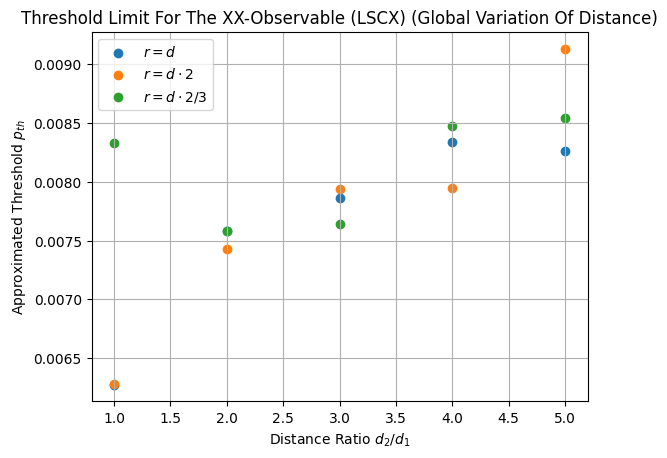

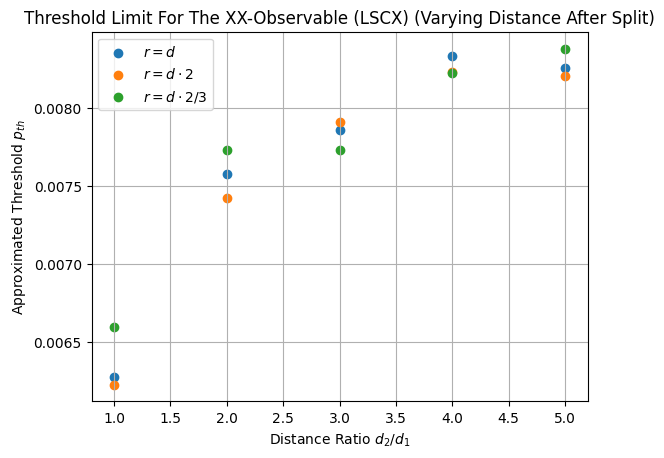

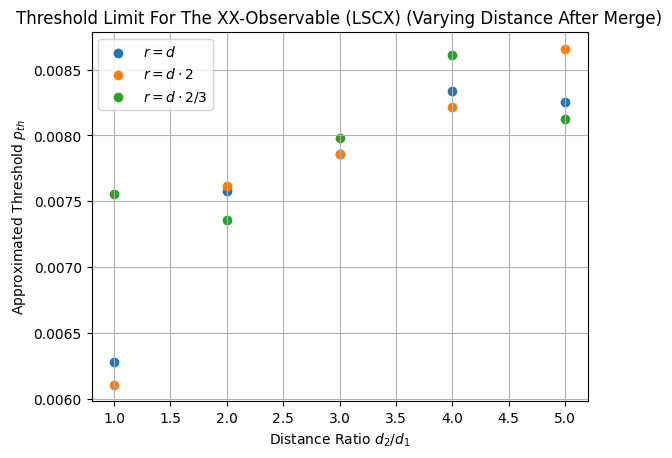

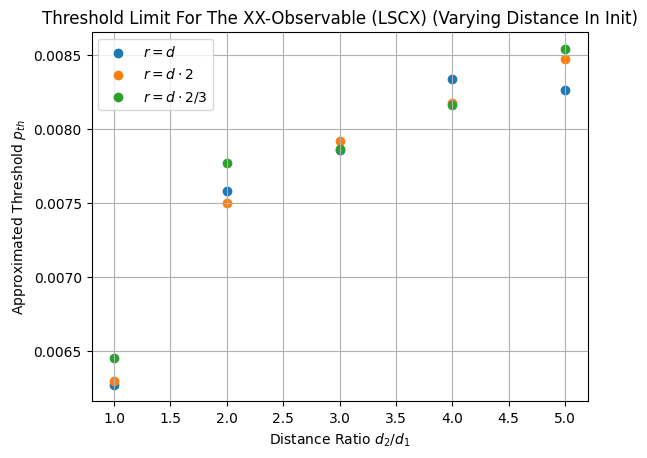

<Figure size 640x480 with 0 Axes>

In [13]:
data_array_norm = []
data_array_double = []
data_array_3 = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double.append([threshold_approx(red_dict_double[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3.append([threshold_approx(red_dict_3[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double = [point[1] for point in data_array_double]
y_vals_double = [point[0] for point in data_array_double]
x_vals_3 = [point[1] for point in data_array_3]
y_vals_3 = [point[0] for point in data_array_3]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double, y_vals_double, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3, y_vals_3, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Global Variation Of Distance)")
plt.legend()
plt.grid(True)

plt.figure()

#####################################
# Plot for Distance increase in Split
#####################################

data_array_norm = []
data_array_double_split = []
data_array_3_split = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_split.append([threshold_approx(red_dict_double_split[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_split.append([threshold_approx(red_dict_3_split[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_split = [point[1] for point in data_array_double_split]
y_vals_double_split = [point[0] for point in data_array_double_split]
x_vals_3_split = [point[1] for point in data_array_3_split]
y_vals_3_split = [point[0] for point in data_array_3_split]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_split, y_vals_double_split, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_split, y_vals_3_split, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Varying Distance After Split)")
plt.legend()
plt.grid(True)

plt.figure()

#####################################
# Plot for Distance increase in Merge
#####################################

data_array_norm = []
data_array_double_merge = []
data_array_3_merge = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_merge.append([threshold_approx(red_dict_double_merge[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_merge.append([threshold_approx(red_dict_3_merge[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_merge = [point[1] for point in data_array_double_merge]
y_vals_double_merge = [point[0] for point in data_array_double_merge]
x_vals_3_merge = [point[1] for point in data_array_3_merge]
y_vals_3_merge = [point[0] for point in data_array_3_merge]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_merge, y_vals_double_merge, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_merge, y_vals_3_merge, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Varying Distance After Merge)")
plt.legend()
plt.grid(True)

plt.figure()

####################################
# Plot for Distance increase in Init
####################################

data_array_norm = []
data_array_double_init = []
data_array_3_init = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_init.append([threshold_approx(red_dict_double_init[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_init.append([threshold_approx(red_dict_3_init[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_init = [point[1] for point in data_array_double_init]
y_vals_double_init = [point[0] for point in data_array_double_init]
x_vals_3_init = [point[1] for point in data_array_3_init]
y_vals_3_init = [point[0] for point in data_array_3_init]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_init, y_vals_double_init, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_init, y_vals_3_init, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Varying Distance In Init)")
plt.legend()
plt.grid(True)

plt.figure()